This notebook gives analysis on basis of AFT model and also checks for performance on holdout dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew
from lifelines import LogNormalAFTFitter
from lifelines.utils import k_fold_cross_validation, concordance_index
from src.config import Paths, ModelConfig
import joblib

In [2]:
# load the data 
df = pd.read_csv(Paths.encoded_data)

DURATION_COL = ModelConfig.duration_col
EVENT_COL    = ModelConfig.event_col

df = df.drop(columns=[c for c in ModelConfig.cols_to_drop if c in df.columns])

print("Shape:", df.shape)
df.head()

Shape: (7043, 10)


,Age,Tenure_in_Months,Churn_status,gender_e,married_e,paper_e,offer_e,Contract_e,Payment_Method_e,Internet_Type_Fiber Optic
0,37,9,0,0,1,1,0,1,1,0
1,46,9,0,1,0,0,0,0,1,0
2,50,4,1,1,0,1,1,0,0,1
3,78,13,1,1,1,1,1,0,0,1
4,75,3,1,0,1,1,0,0,1,1


In [3]:
# load the model 
aft = joblib.load(Paths.model) 

How does expected survival time change with Age?

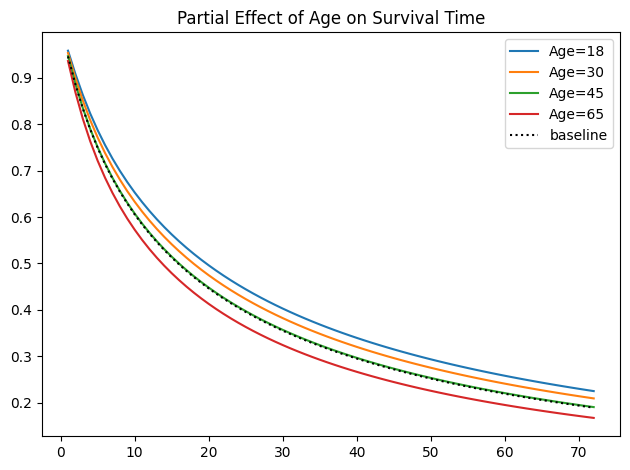

In [4]:
aft.plot_partial_effects_on_outcome(
    covariates=['Age'],
    values=[18, 30, 45, 65],
    plot_baseline=True
)
plt.title("Partial Effect of Age on Survival Time")
plt.tight_layout()
plt.show()

Residual diagnostics (assumption check)

C:\Users\abhin\AppData\Local\Temp\ipykernel_8820\2498026568.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale                  = np.exp(aft_model.params_.loc['sigma_'][0])


Skewness: 0.2612
(Close to 0 = residuals approximately normal = assumption holds)


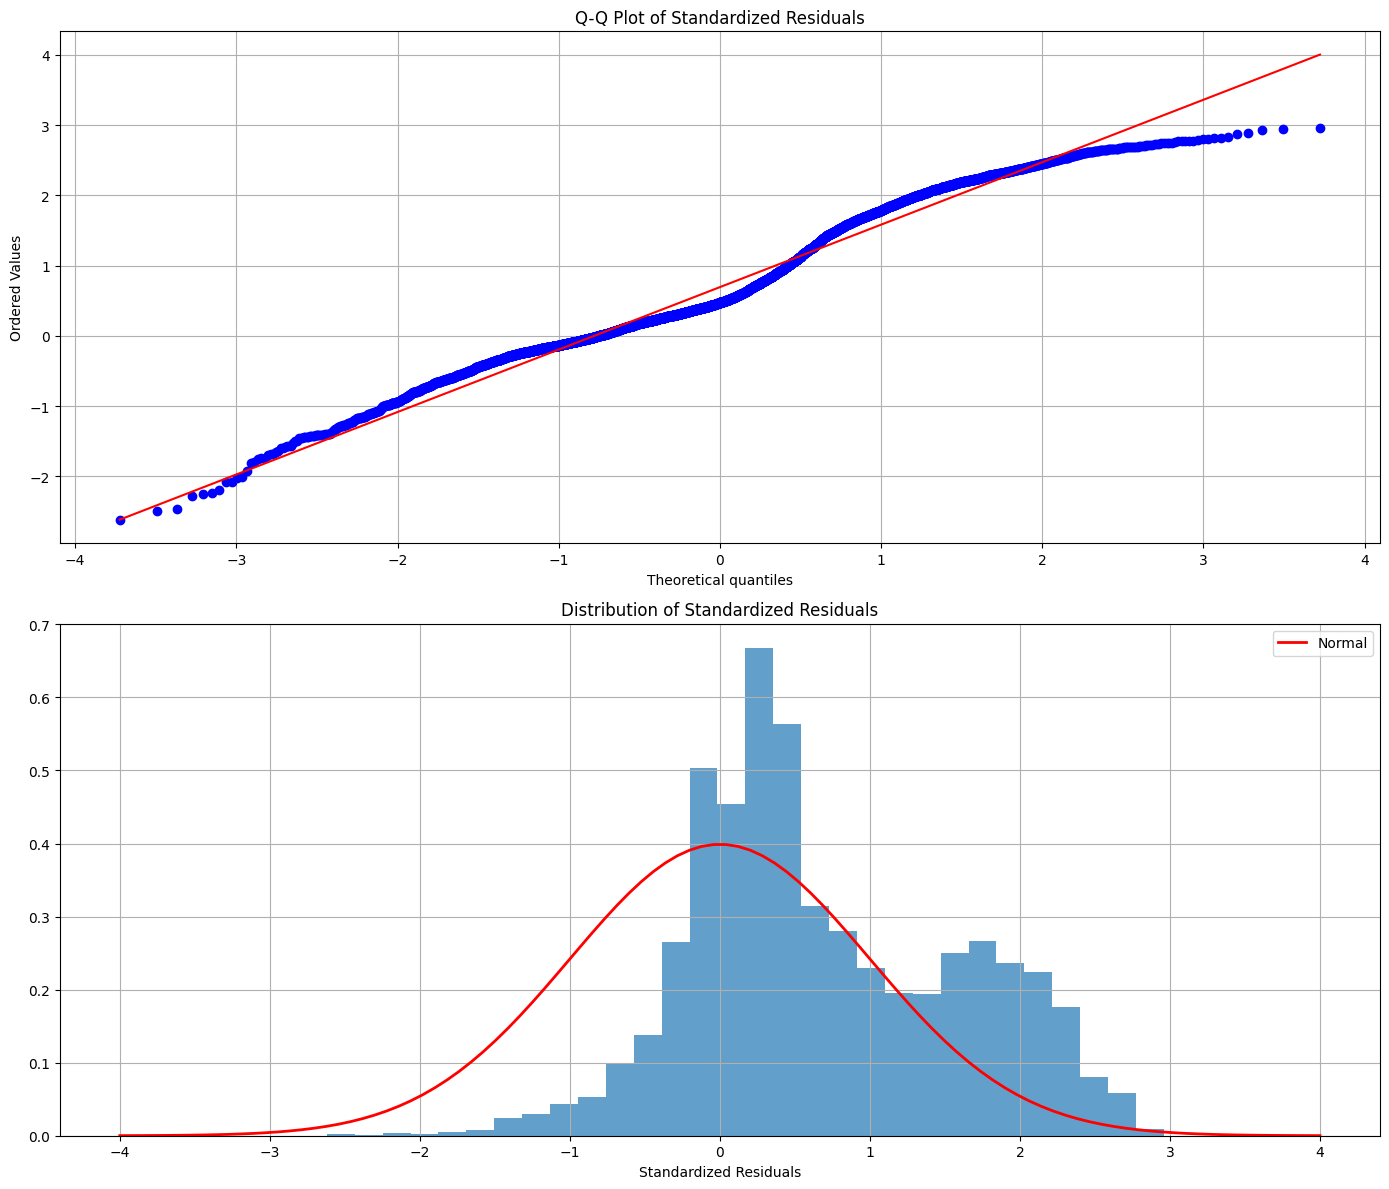

In [5]:
def calculate_and_plot_aft_residuals(aft_model, df, duration_col=DURATION_COL):
    mu_features = aft_model.params_.loc['mu_'].index.tolist()
    if 'Intercept' in mu_features:
        mu_features.remove('Intercept')

    X                      = df[mu_features].copy()
    actual_durations       = df[duration_col].values
    coefficients           = aft_model.params_.loc['mu_'][mu_features].values
    Xbeta                  = np.dot(X, coefficients)
    log_residuals          = np.log(actual_durations) - Xbeta
    scale                  = np.exp(aft_model.params_.loc['sigma_'][0])
    standardized_residuals = log_residuals / scale

    print(f"Skewness: {skew(standardized_residuals):.4f}")
    print("(Close to 0 = residuals approximately normal = assumption holds)")

    fig, axes = plt.subplots(2, 1, figsize=(14, 12))

    stats.probplot(standardized_residuals, dist="norm", plot=axes[0])
    axes[0].set_title("Q-Q Plot of Standardized Residuals")
    axes[0].grid(True)

    axes[1].hist(standardized_residuals, bins=30, density=True, alpha=0.7)
    x = np.linspace(-4, 4, 100)
    axes[1].plot(x, stats.norm.pdf(x), 'r-', linewidth=2, label='Normal')
    axes[1].set_title("Distribution of Standardized Residuals")
    axes[1].set_xlabel("Standardized Residuals")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return standardized_residuals

residuals = calculate_and_plot_aft_residuals(aft, df)

Residual bias by group 

C:\Users\abhin\AppData\Local\Temp\ipykernel_8820\3759732193.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale      = np.exp(aft_model.params_.loc['sigma_'][0])



Mean residuals by Contract_e:
Contract_e
0   -0.579
1   -1.790
Name: standardized_residuals, dtype: float64
(Values near 0 = no group bias)


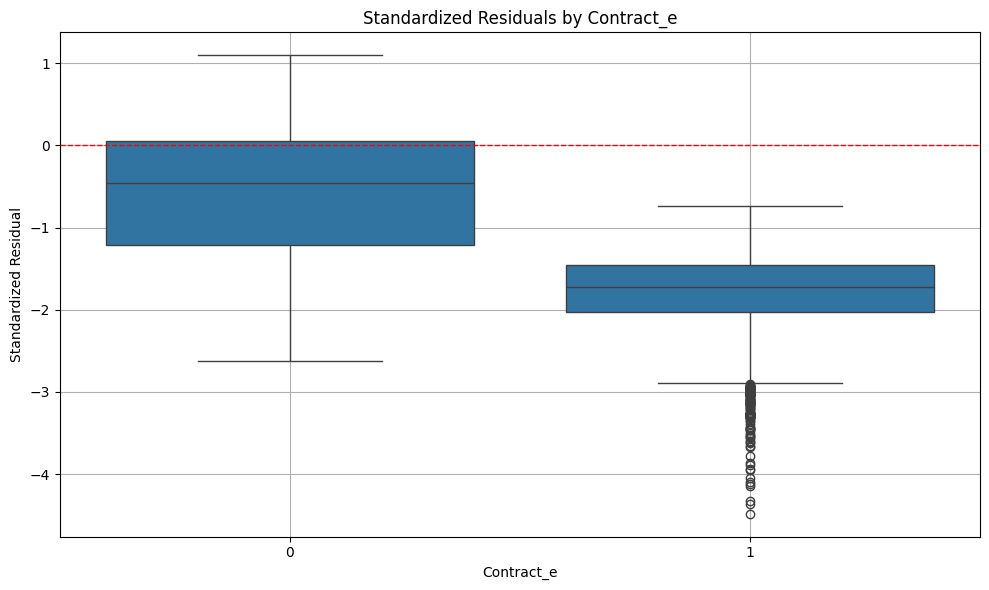

C:\Users\abhin\AppData\Local\Temp\ipykernel_8820\3759732193.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  scale      = np.exp(aft_model.params_.loc['sigma_'][0])



Mean residuals by Payment_Method_e:
Payment_Method_e
0   -0.921
1   -1.558
Name: standardized_residuals, dtype: float64
(Values near 0 = no group bias)


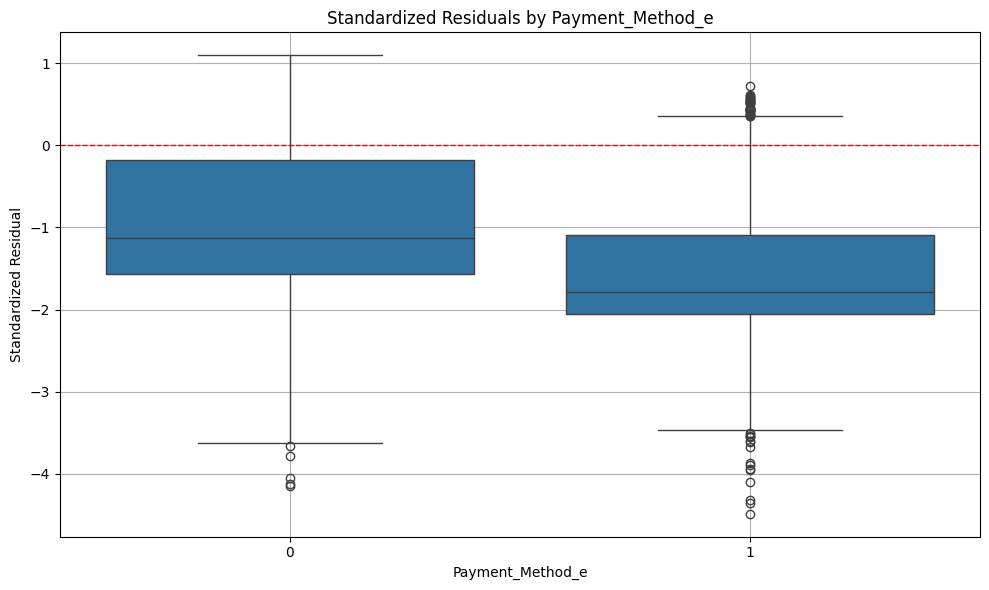

In [6]:
def plot_residuals_by_group(aft_model, df, group_col, duration_col=DURATION_COL):
    log_actual = np.log(df[duration_col].values)
    log_pred   = np.log(aft_model.predict_median(df).values)
    scale      = np.exp(aft_model.params_.loc['sigma_'][0])
    resids     = (log_actual - log_pred) / scale

    df_copy = df.copy()
    df_copy['standardized_residuals'] = resids

    group_means = df_copy.groupby(group_col)['standardized_residuals'].mean()
    print(f"\nMean residuals by {group_col}:\n{group_means.round(3)}")
    print("(Values near 0 = no group bias)")

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_copy, x=group_col, y='standardized_residuals')
    plt.axhline(0, color='red', linestyle='--', linewidth=1)
    plt.title(f"Standardized Residuals by {group_col}")
    plt.ylabel("Standardized Residual")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_residuals_by_group(aft, df, group_col='Contract_e')
plot_residuals_by_group(aft, df, group_col='Payment_Method_e')

final eval on holdout data set 

In [ ]:
# Final evaluation on holdout set (never seen during training)
df_holdout = pd.read_csv(Paths.encoded_data.parent.parent / 'test' / 'holdout_set.csv')



holdout_predictions = aft.predict_median(df_holdout)
holdout_c_index = concordance_index(
    df_holdout[DURATION_COL],
    holdout_predictions,
    df_holdout[EVENT_COL]
)

print(f"Holdout C-index: {holdout_c_index:.3f}")
print(f"CV C-index:      ~0.83")
print("(Close values = model generalises well, no overfitting)")

Holdout C-index: 0.824
CV C-index:      ~0.83
(Close values = model generalises well, no overfitting)
